Active offenses          80
Harvest/audit            28  (35% of intake)
Decided                  52  (65% of intake)
Rejected                 16  (31% of decided)
Approved                 36  (69% of decided)
Classified by AI         25  (69% of approved)
Awaiting classification  11  (31% of approved)


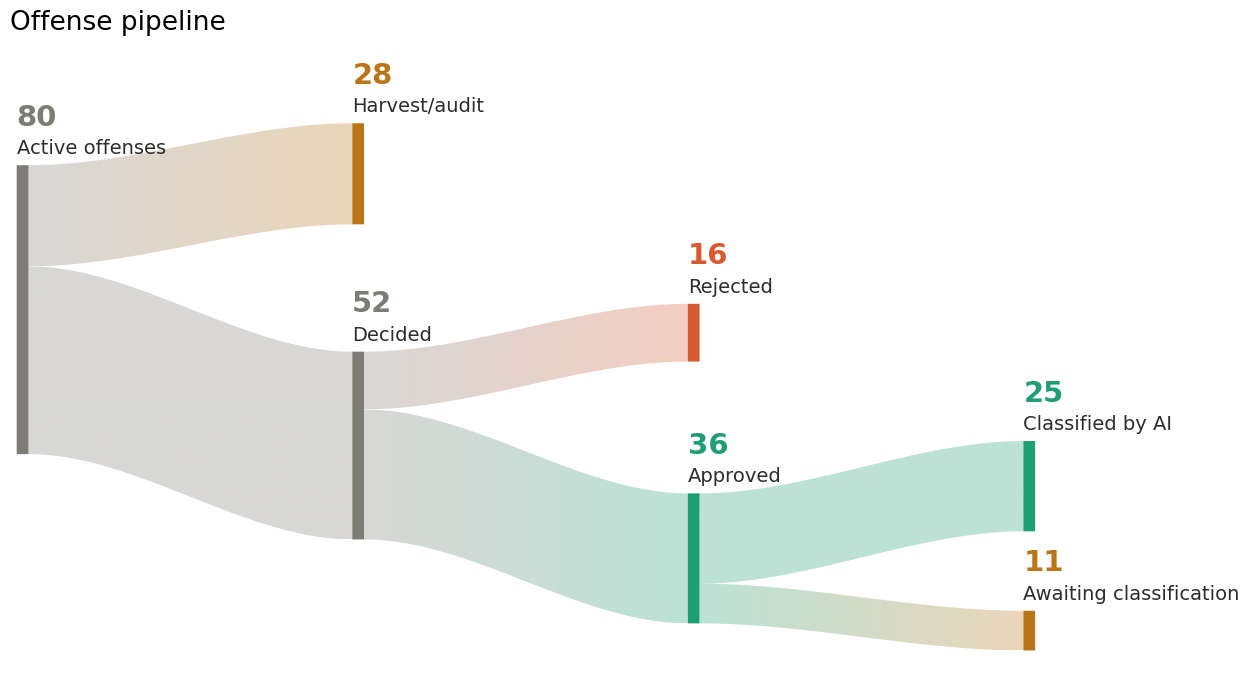

In [10]:
"""
Offense pipeline Sankey.

Edit the PIPELINE COUNTS block, then run:
    python offense_pipeline.py

Requires: pip install matplotlib
"""

import textwrap

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch, Polygon

# ============================================================
# PIPELINE COUNTS — edit these four numbers
# ============================================================
# Active offenses branches into harvest/audit and decided.
# Decided branches into rejected and approved. Approved branches
# into classified and awaiting. Approved, decided and the total
# are derived, so the parts can never disagree with the whole.

IN_HARVEST = 28     # active, still in harvest/audit
REJECTED = 16       # decided, rejected
CLASSIFIED = 25     # approved, classified by AI
AWAITING = 11       # approved, not yet classified

EXPECTED_TOTAL = 80   # sanity check against your source; None to skip

# ============================================================
# LABELS — rename any node here
# ============================================================

LABEL_TOTAL = "Active offenses"
LABEL_HARVEST = "Harvest/audit"
LABEL_DECIDED = "Decided"
LABEL_REJECTED = "Rejected"
LABEL_APPROVED = "Approved"
LABEL_CLASSIFIED = "Classified by AI"
LABEL_AWAITING = "Awaiting classification"

# ============================================================
# APPEARANCE
# ============================================================

TITLE = "Offense pipeline"

COUNT_FONTSIZE = 21      # the big number
NAME_FONTSIZE = 14       # the label under it
TITLE_FONTSIZE = 19

FIGSIZE = (13, 7)
NAME_WRAP = 24           # characters before a node name wraps

COLUMN_PITCH = 1.00      # horizontal distance between columns
BAR_WIDTH = 0.035        # node bar thickness, in x units
LEAF_GAP = 22            # vertical gap between stacked leaves, in counts
RIBBON_ALPHA = 0.30
RIBBON_STEPS = 160       # smoothness of the curved edges

# Grey for aggregates, amber for queued work, coral for terminal
# rejection, teal for cleared through
GREY = "#7C7B74"
AMBER = "#BA7517"
CORAL = "#D85A30"
TEAL = "#1D9E75"
NAME_INK = "#2C2C2A"

# ============================================================
# DERIVED TOTALS
# ============================================================

APPROVED = CLASSIFIED + AWAITING
DECIDED = REJECTED + APPROVED
TOTAL = IN_HARVEST + DECIDED


def build_tree():
    """The pipeline as a tree. Children must sum to their parent."""
    return {
        "name": LABEL_TOTAL, "value": TOTAL, "color": GREY,
        "children": [
            {"name": LABEL_HARVEST, "value": IN_HARVEST, "color": AMBER},
            {"name": LABEL_DECIDED, "value": DECIDED, "color": GREY,
             "children": [
                 {"name": LABEL_REJECTED, "value": REJECTED, "color": CORAL},
                 {"name": LABEL_APPROVED, "value": APPROVED, "color": TEAL,
                  "children": [
                      {"name": LABEL_CLASSIFIED, "value": CLASSIFIED,
                       "color": TEAL},
                      {"name": LABEL_AWAITING, "value": AWAITING,
                       "color": AMBER},
                  ]},
             ]},
        ],
    }


def layout(node, depth=0, cursor=None):
    """Give every node a column and a vertical span.

    Heights are proportional to counts. Leaves are stacked top to
    bottom with a fixed gap, and each parent is centred on its
    children — so the branches stay spread out and readable instead
    of packing tight against each other.
    """
    if cursor is None:
        cursor = [0.0]

    node["x"] = depth * COLUMN_PITCH
    children = node.get("children")

    if not children:
        node["top"] = cursor[0]
        node["bottom"] = cursor[0] + node["value"]
        cursor[0] = node["bottom"] + LEAF_GAP
        return

    for child in children:
        layout(child, depth + 1, cursor)

    centre = sum((c["top"] + c["bottom"]) / 2 for c in children) / len(children)
    node["top"] = centre - node["value"] / 2
    node["bottom"] = centre + node["value"] / 2


def walk(node):
    yield node
    for child in node.get("children", []):
        yield from walk(child)


def ribbon(ax, x0, x1, src_top, src_bottom, dst_top, dst_bottom,
           from_color, to_color):
    """A curved band that fades from the parent's colour to the child's."""
    t = np.linspace(0, 1, RIBBON_STEPS)
    s = 3 * t**2 - 2 * t**3               # smoothstep: flat at both ends
    x = x0 + t * (x1 - x0)
    upper = src_top + s * (dst_top - src_top)
    lower = src_bottom + s * (dst_bottom - src_bottom)

    verts = np.concatenate([
        np.column_stack([x, upper]),
        np.column_stack([x[::-1], lower[::-1]]),
    ])
    clip = Polygon(verts, closed=True, facecolor="none", edgecolor="none")
    ax.add_patch(clip)

    cmap = LinearSegmentedColormap.from_list("ribbon", [from_color, to_color])
    gradient = ax.imshow(
        np.linspace(0, 1, 256).reshape(1, -1), cmap=cmap, aspect="auto",
        origin="lower", alpha=RIBBON_ALPHA, zorder=1,
        extent=[x0, x1, min(upper.min(), lower.min()),
                max(upper.max(), lower.max())])
    gradient.set_clip_path(clip)


def draw(ax, root):
    for node in walk(root):
        height = node["bottom"] - node["top"]
        ax.add_patch(FancyBboxPatch(
            (node["x"], node["top"]), BAR_WIDTH, height,
            boxstyle="round,pad=0,rounding_size=0.012",
            facecolor=node["color"], edgecolor="none", zorder=3))

        # Labels sit above the bar, so they never cross a ribbon.
        ax.annotate(textwrap.fill(node["name"], NAME_WRAP),
                    xy=(node["x"], node["top"]), xytext=(0, 5),
                    textcoords="offset points", ha="left", va="bottom",
                    fontsize=NAME_FONTSIZE, color=NAME_INK, zorder=4)
        ax.annotate(str(node["value"]),
                    xy=(node["x"], node["top"]), xytext=(0, 24),
                    textcoords="offset points", ha="left", va="bottom",
                    fontsize=COUNT_FONTSIZE, fontweight="bold",
                    color=node["color"], zorder=4)

        # Each child leaves from its own slice of the parent bar.
        cursor = node["top"]
        for child in node.get("children", []):
            ribbon(ax, node["x"] + BAR_WIDTH, child["x"],
                   cursor, cursor + child["value"],
                   child["top"], child["bottom"],
                   node["color"], child["color"])
            cursor += child["value"]


def build_figure():
    root = build_tree()
    layout(root)

    nodes = list(walk(root))
    x_max = max(n["x"] for n in nodes) + BAR_WIDTH
    y_min = min(n["top"] for n in nodes)
    y_max = max(n["bottom"] for n in nodes)
    pad = (y_max - y_min) * 0.14

    fig, ax = plt.subplots(figsize=FIGSIZE)
    draw(ax, root)

    ax.set_xlim(-0.02, x_max + 0.62)
    ax.set_ylim(y_max + pad * 0.4, y_min - pad)   # inverted: top row first
    ax.axis("off")
    ax.set_title(TITLE, fontsize=TITLE_FONTSIZE, loc="left", pad=14)
    fig.tight_layout()
    return fig


def percent(part, whole):
    return f"{100 * part / whole:.0f}%" if whole else "n/a"


def print_summary():
    if EXPECTED_TOTAL is not None and TOTAL != EXPECTED_TOTAL:
        print(f"WARNING: parts sum to {TOTAL}, expected {EXPECTED_TOTAL}")

    print(f"{LABEL_TOTAL:<24}{TOTAL:>3}")
    print(f"{LABEL_HARVEST:<24}{IN_HARVEST:>3}  ({percent(IN_HARVEST, TOTAL)} of intake)")
    print(f"{LABEL_DECIDED:<24}{DECIDED:>3}  ({percent(DECIDED, TOTAL)} of intake)")
    print(f"{LABEL_REJECTED:<24}{REJECTED:>3}  ({percent(REJECTED, DECIDED)} of decided)")
    print(f"{LABEL_APPROVED:<24}{APPROVED:>3}  ({percent(APPROVED, DECIDED)} of decided)")
    print(f"{LABEL_CLASSIFIED:<24}{CLASSIFIED:>3}  ({percent(CLASSIFIED, APPROVED)} of approved)")
    print(f"{LABEL_AWAITING:<24}{AWAITING:>3}  ({percent(AWAITING, APPROVED)} of approved)")


def main():
    print_summary()
    build_figure()
    plt.show()


if __name__ == "__main__":
    main()